# Exploring Bias in the Adult Income Dataset

## DATA6550 – Data Ethics and Responsibility

### By Divya Sai Sukanya



## Import Libraries:

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

## Load the Dataset

In [23]:
df = pd.read_csv( "/content/adult.csv",)
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## Dataset Overview

In [24]:
print("Shape of dataset:", df.shape)
df.info()
df.describe()

Shape of dataset: (32561, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [25]:
df.isnull().sum()
df = df.dropna()
print(df.shape)

(32561, 15)


## Income Distribution

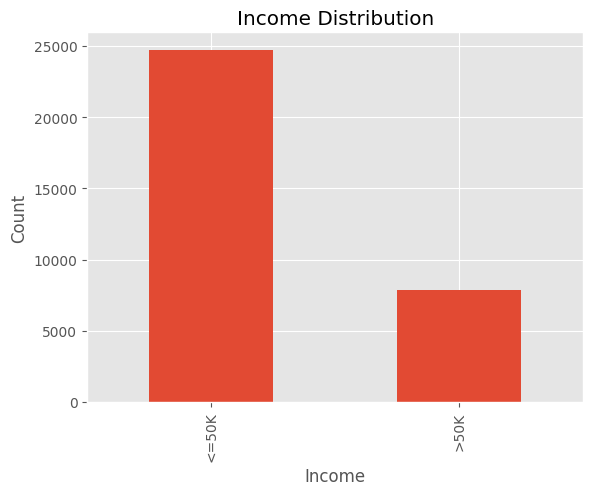

In [26]:
df["income"].value_counts().plot(kind="bar")
plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Count")
plt.show()

The graph shows that most people in the dataset earn 50k or less each year, while a much smaller number earn more than 50k. This indicates that the dataset is imbalanced, with the lower-income group being much larger than the higher-income group.

## Gender Distribution

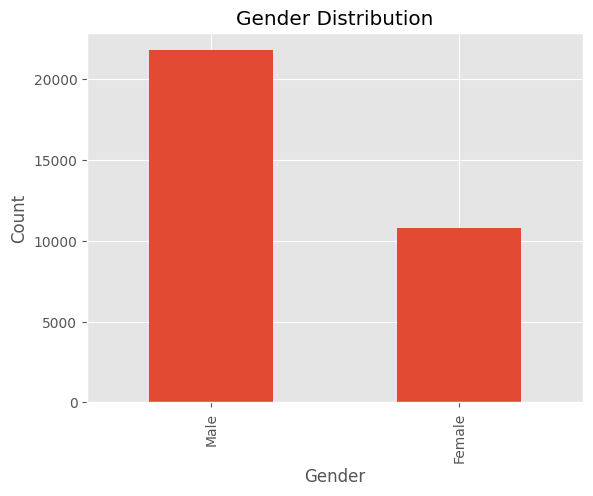

In [27]:
df["sex"].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

The graph shows that there are more males than females in the Adult Income dataset. This imbalance suggests that males are more heavily represented, which may influence the analysis and should be considered when studying bias in the dataset.

## Race Distribution

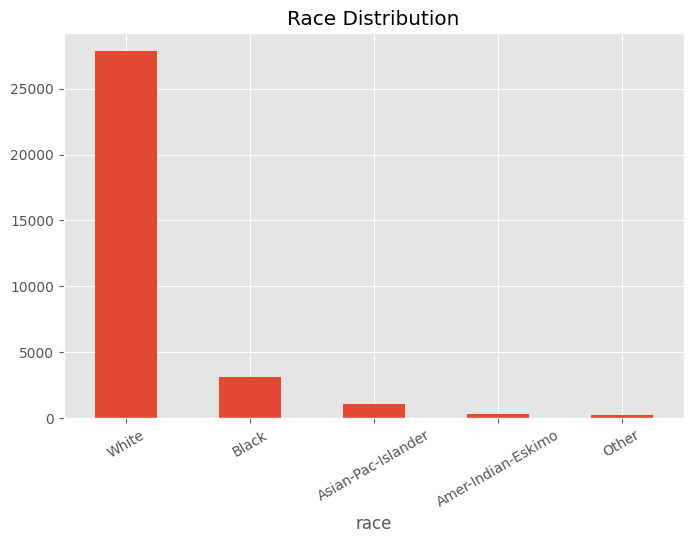

In [28]:
df["race"].value_counts().plot(kind="bar", figsize=(8,5))
plt.xticks(rotation=30)
plt.title("Race Distribution")
plt.show()

From the graph, we can see that most of the people in the dataset belong to the White racial group. The remaining racial groups have considerably fewer records, indicating that the dataset is not evenly distributed across races.

## Education Distribution

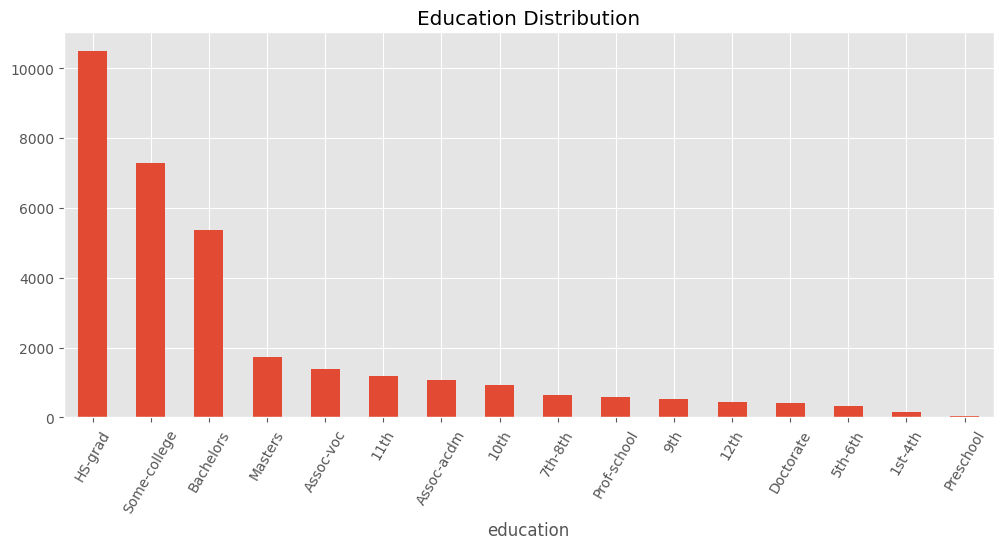

In [29]:
df["education"].value_counts().plot(kind="bar", figsize=(12,5))
plt.xticks(rotation=60)
plt.title("Education Distribution")
plt.show()

The chart shows that HS-grad is the most common education level among the individuals in the dataset. Fewer people have advanced degrees like Master's or Doctorate, which means the dataset contains more individuals with lower or mid-level education backgrounds.

## Income by Gender

income  <=50K  >50K
sex                
Female   9592  1179
Male    15128  6662


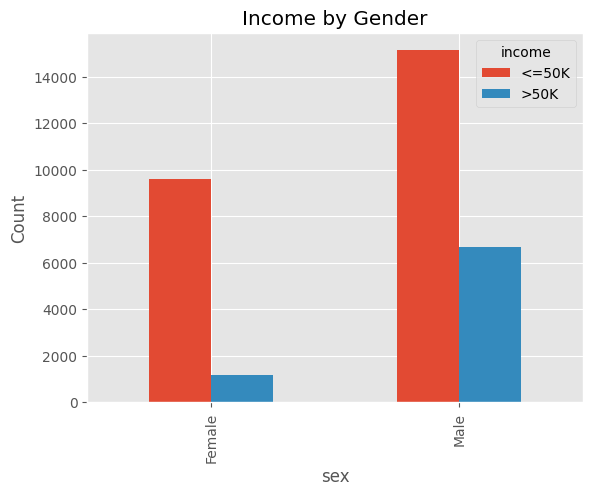

In [30]:
gender_income = pd.crosstab(df["sex"], df["income"])
print(gender_income)
gender_income.plot(kind="bar")
plt.title("Income by Gender")
plt.ylabel("Count")
plt.show()

From the graph, we can see that the majority of both males and females belong to the ≤50K income group. However, males have a much higher number of individuals earning more than $50K than females, indicating difference in income distribution by gender.

## Income by Race

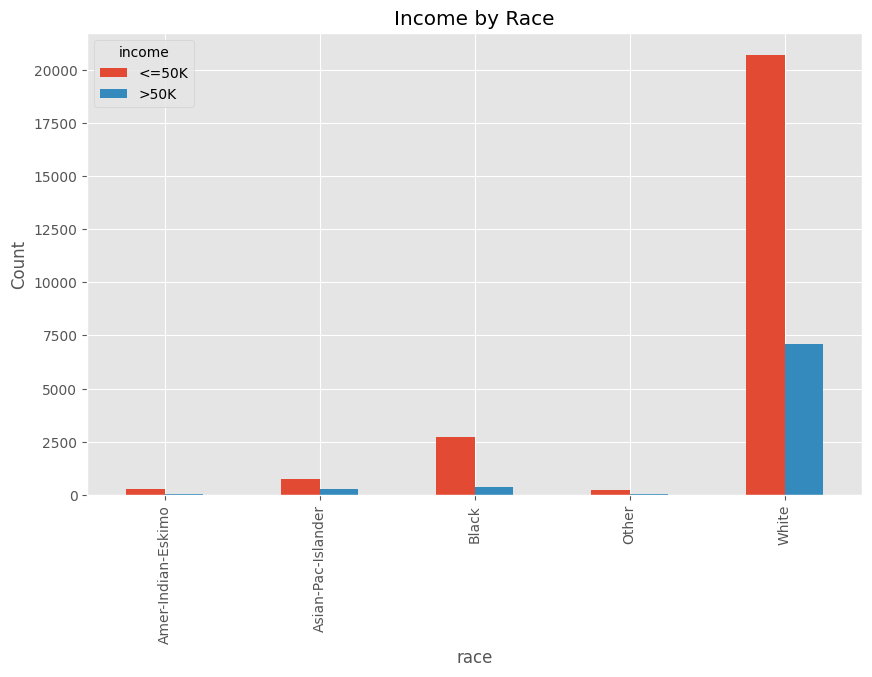

In [31]:
race_income = pd.crosstab(df["race"], df["income"])
race_income.plot(kind="bar", figsize=(10,6))
plt.title("Income by Race")
plt.ylabel("Count")
plt.show()

The chart shows that most individuals in every racial group earn $50K or less per year. The White group has the highest number of individuals in both income categories because it is the largest group represented in the dataset.

## Income by Education

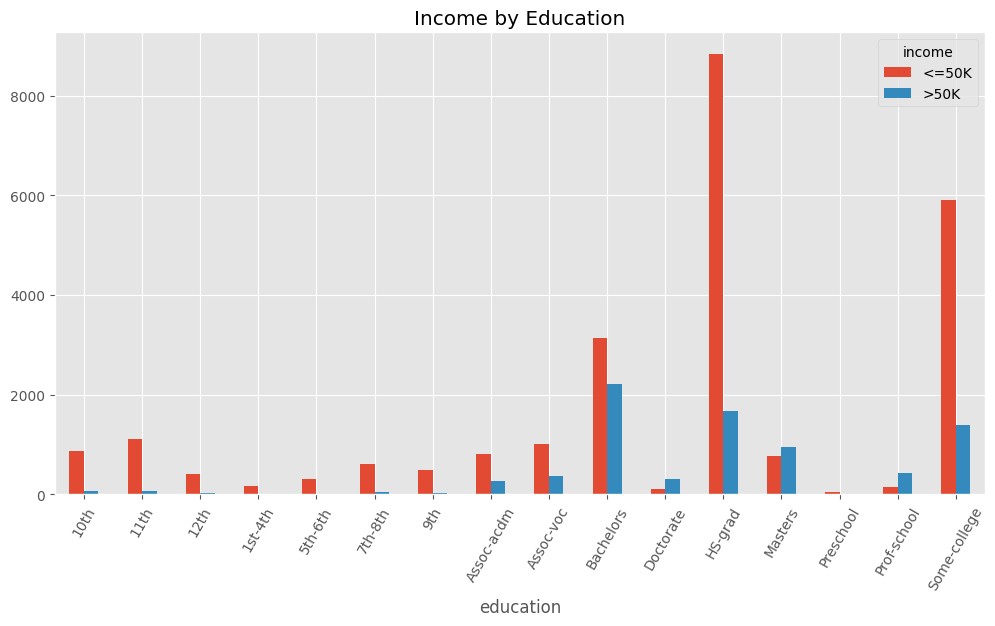

In [32]:
education_income = pd.crosstab(df["education"], df["income"])
education_income.plot(kind="bar", figsize=(12,6))
plt.xticks(rotation=60)
plt.title("Income by Education")
plt.show()

The chart shows that individuals with a Bachelor's, Master's, Professional School, or Doctorate degree have a higher number of people earning more than 50K compared to lower education levels. In contrast, most individuals with only a high school education or some college earn $50K or less, suggesting that education level is associated with income.

## Hours Worked

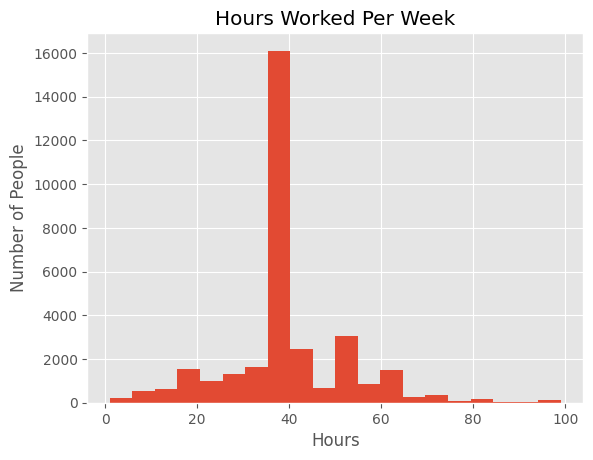

In [33]:
plt.hist(df["hours.per.week"], bins=20)
plt.title("Hours Worked Per Week")
plt.xlabel("Hours")
plt.ylabel("Number of People")
plt.show()

From the graph, we can see that the highest number of people work approximately 40 hours each week. There are fewer individuals who work very short or very long hours, making 40 hours the most common work schedule.

## Correlation Analysis

In [34]:
numeric = df.select_dtypes(include=np.number)
corr = numeric.corr()
print(corr)

                     age    fnlwgt  education.num  capital.gain  capital.loss  \
age             1.000000 -0.076646       0.036527      0.077674      0.057775   
fnlwgt         -0.076646  1.000000      -0.043195      0.000432     -0.010252   
education.num   0.036527 -0.043195       1.000000      0.122630      0.079923   
capital.gain    0.077674  0.000432       0.122630      1.000000     -0.031615   
capital.loss    0.057775 -0.010252       0.079923     -0.031615      1.000000   
hours.per.week  0.068756 -0.018768       0.148123      0.078409      0.054256   

                hours.per.week  
age                   0.068756  
fnlwgt               -0.018768  
education.num         0.148123  
capital.gain          0.078409  
capital.loss          0.054256  
hours.per.week        1.000000  


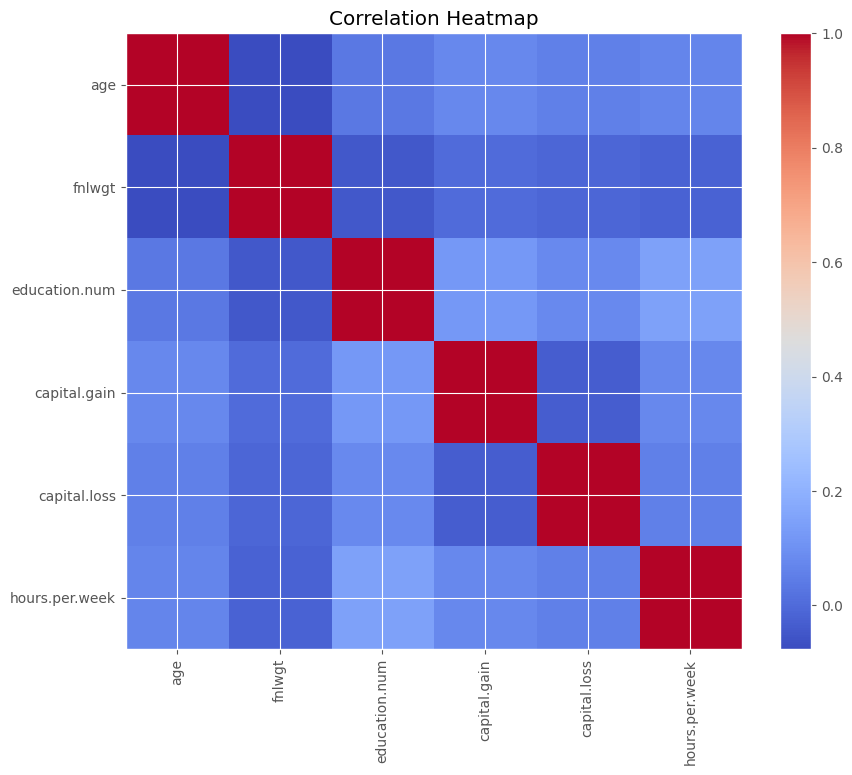

In [35]:
# Plot heatmap
plt.figure(figsize=(10,8))
plt.imshow(corr, cmap='coolwarm', interpolation='nearest')
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")
plt.show()

The correlation analysis shows that the numerical features are only weakly correlated, meaning no single variable has a strong linear relationship with another. This suggests that multiple factors, such as education, age, and work hours, should be considered together when analyzing income and potential bias.